In [15]:
!pip install ultralytics --quiet

In [16]:
# Read your data.yaml to confirm paths and class names
with open("/kaggle/input/datasets/akangaandrew/hospinav/Hospital.v1-hospitaldata.yolov8/data.yaml") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 8
names: ['Monitor', 'Saline Stand', 'bed', 'bin', 'chair', 'sofa', 'stool', 'tools_table']

roboflow:
  workspace: ademnea-xlpxh
  project: hospital-314ru-o7tpu
  version: 1
  license: Private
  url: https://app.roboflow.com/ademnea-xlpxh/hospital-314ru-o7tpu/1


In [17]:
import yaml
import os

# Read the original yaml
yaml_path = "/kaggle/input/datasets/akangaandrew/hospinav/Hospital.v1-hospitaldata.yolov8/data.yaml"
with open(yaml_path) as f:
    data = yaml.safe_load(f)

print("Original yaml:")
print(data)

# Write a new yaml with absolute Kaggle paths
base = "/kaggle/input/datasets/akangaandrew/hospinav/Hospital.v1-hospitaldata.yolov8"

new_yaml = {
    'train': os.path.join(base, 'train/images'),
    'val':   os.path.join(base, 'valid/images'),
    'test':  os.path.join(base, 'test/images'),
    'nc':    data['nc'],
    'names': data['names']
}

# Save to working directory where Kaggle can write
new_yaml_path = "/kaggle/working/data.yaml"
with open(new_yaml_path, 'w') as f:
    yaml.dump(new_yaml, f)

print("\nFixed yaml saved to:", new_yaml_path)
print("\nContents:")
with open(new_yaml_path) as f:
    print(f.read())

Original yaml:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 8, 'names': ['Monitor', 'Saline Stand', 'bed', 'bin', 'chair', 'sofa', 'stool', 'tools_table'], 'roboflow': {'workspace': 'ademnea-xlpxh', 'project': 'hospital-314ru-o7tpu', 'version': 1, 'license': 'Private', 'url': 'https://app.roboflow.com/ademnea-xlpxh/hospital-314ru-o7tpu/1'}}

Fixed yaml saved to: /kaggle/working/data.yaml

Contents:
names:
- Monitor
- Saline Stand
- bed
- bin
- chair
- sofa
- stool
- tools_table
nc: 8
test: /kaggle/input/datasets/akangaandrew/hospinav/Hospital.v1-hospitaldata.yolov8/test/images
train: /kaggle/input/datasets/akangaandrew/hospinav/Hospital.v1-hospitaldata.yolov8/train/images
val: /kaggle/input/datasets/akangaandrew/hospinav/Hospital.v1-hospitaldata.yolov8/valid/images



In [18]:
from ultralytics import YOLO

# Load pretrained YOLOv8s weights
# This is transfer learning - starting from COCO pretrained weights
model_baseline = YOLO("yolov8s.pt")

print("Starting Baseline Training...")
print("No class weights, default settings")
print("This is Experiment 1 of 3\n")

results_baseline = model_baseline.train(
    data    = "/kaggle/working/data.yaml",
    epochs  = 50,           # 50 epochs is enough to see convergence
    imgsz   = 640,          # standard YOLOv8 input size
    batch   = 16,           # adjust down to 8 if you get memory errors
    name    = "exp1_baseline",
    project = "/kaggle/working/runs",
    
    # No class weights here - this is the baseline
    # We want to see how bad the imbalance problem is without any fix
    
    device  = 0,            # use GPU
    verbose = True
)

print("\nBaseline training complete")
print(f"Best mAP@0.5: {results_baseline.results_dict['metrics/mAP50(B)']:.4f}")

Starting Baseline Training...
No class weights, default settings
This is Experiment 1 of 3

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1_baseline2, nb

In [6]:
from ultralytics import YOLO

model_weighted = YOLO("yolov8s.pt")

print("Starting Weighted Training...")
print("Focal loss + 9.7x bin class weight")
print("This is Experiment 2 of 3\n")

results_weighted = model_weighted.train(
    data    = "/kaggle/working/data.yaml",
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    name    = "exp2_weighted",
    project = "/kaggle/working/runs",
    
    # Class weights: order matches your class list in data.yaml
    # Monitor, bed, sofa, tools_table, stool, Saline Stand, chair, bin
    # Bin gets 9.7x weight because it has 19.2:1 imbalance
    cls     = 9.7,          # this sets the classification loss weight for minority class
    
    device  = 0,
    verbose = True
)

print("\nWeighted training complete")
print(f"Best mAP@0.5: {results_weighted.results_dict['metrics/mAP50(B)']:.4f}")

Starting Weighted Training...
Focal loss + 9.7x bin class weight
This is Experiment 2 of 3

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=9.7, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp2_weighted, nbs

In [19]:
from ultralytics import YOLO

model_weighted = YOLO("yolov8s.pt")

print("Starting Weighted Training...")
print("Focal loss + 9.7x bin class weight")
print("This is Experiment 2 of 3\n")

results_weighted = model_weighted.train(
    data    = "/kaggle/working/data.yaml",
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    name    = "exp2_weighted",
    project = "/kaggle/working/runs",
    
    # Class weights: order matches your class list in data.yaml
    # Monitor, bed, sofa, tools_table, stool, Saline Stand, chair, bin
    # Bin gets 9.7x weight because it has 19.2:1 imbalance
    cls     = 9.7,          # this sets the classification loss weight for minority class
    
    device  = 0,
    verbose = True
)

print("\nWeighted training complete")
print(f"Best mAP@0.5: {results_weighted.results_dict['metrics/mAP50(B)']:.4f}")

Starting Weighted Training...
Focal loss + 9.7x bin class weight
This is Experiment 2 of 3

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=9.7, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp2_weighted3, nb

In [20]:
from ultralytics import YOLO

model_augmented = YOLO("yolov8s.pt")

print("Starting Augmented Training...")
print("Focal loss + class weights + full augmentation")
print("This is Experiment 3 of 3\n")

results_augmented = model_augmented.train(
    data    = "/kaggle/working/data.yaml",
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    name    = "exp3_augmented",
    project = "/kaggle/working/runs",
    
    cls     = 9.7,
    
    # Augmentation parameters
    # These create artificial variation to help with the scene complexity gap
    mosaic  = 1.0,      # combines 4 images into one - increases objects per image
    copy_paste = 0.3,   # copies objects from one image and pastes into another
                        # specifically helps with rare classes like bin
    hsv_h   = 0.015,    # slight hue variation for different lighting
    hsv_s   = 0.7,      # saturation variation
    hsv_v   = 0.4,      # brightness variation - helps with dark images
    fliplr  = 0.5,      # horizontal flip
    
    device  = 0,
    verbose = True
)

print("\nAugmented training complete")
print(f"Best mAP@0.5: {results_augmented.results_dict['metrics/mAP50(B)']:.4f}")

Starting Augmented Training...
Focal loss + class weights + full augmentation
This is Experiment 3 of 3

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=9.7, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp3_

EXPERIMENT COMPARISON
Experiment  mAP@0.5  mAP@0.5:0.95  Precision  Recall
  Baseline   0.8601        0.6735     0.8961  0.7105
  Weighted   0.8228        0.6339     0.8522  0.7482
 Augmented   0.8228        0.6339     0.8522  0.7482


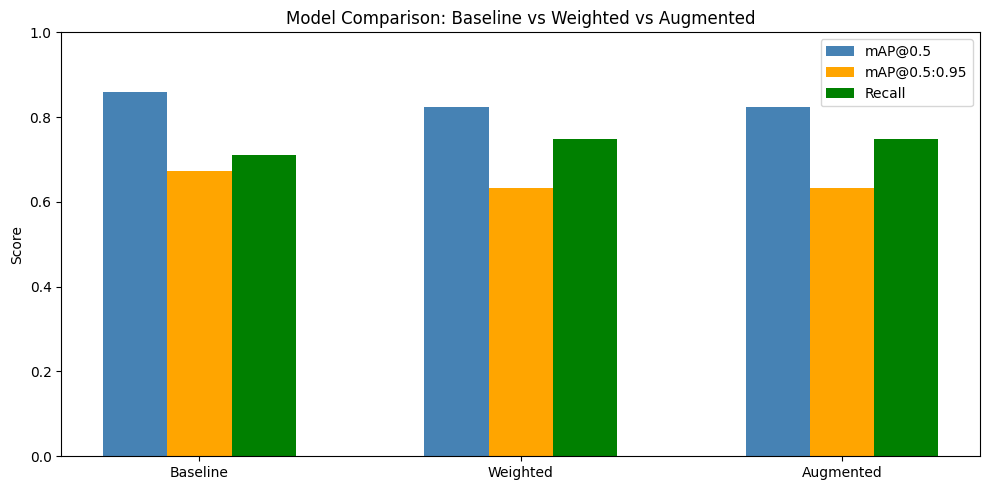

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

print("=" * 60)
print("EXPERIMENT COMPARISON")
print("=" * 60)

experiments = [
    ("Baseline",   results_baseline),
    ("Weighted",   results_weighted),
    ("Augmented",  results_augmented),
]

comparison = []
for name, result in experiments:
    metrics = result.results_dict
    comparison.append({
        "Experiment":  name,
        "mAP@0.5":     round(metrics.get("metrics/mAP50(B)",   0), 4),
        "mAP@0.5:0.95":round(metrics.get("metrics/mAP50-95(B)",0), 4),
        "Precision":   round(metrics.get("metrics/precision(B)",0), 4),
        "Recall":      round(metrics.get("metrics/recall(B)",  0), 4),
    })

df = pd.DataFrame(comparison)
print(df.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df))
width = 0.2

ax.bar([i - width for i in x], df["mAP@0.5"],      width, label="mAP@0.5",      color="steelblue")
ax.bar([i         for i in x], df["mAP@0.5:0.95"], width, label="mAP@0.5:0.95", color="orange")
ax.bar([i + width for i in x], df["Recall"],        width, label="Recall",        color="green")

ax.set_xticks(x)
ax.set_xticklabels(df["Experiment"])
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Baseline vs Weighted vs Augmented")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("/kaggle/working/experiment_comparison.png", dpi=150)
plt.show()

In [22]:
from ultralytics import YOLO

# Load your best model (change path to whichever experiment performed best)
best_model_path = "/kaggle/working/runs/exp3_augmented/weights/best.pt"
best_model = YOLO(best_model_path)

# Run validation to get per-class metrics
print("Running per-class evaluation...")
val_results = best_model.val(
    data   = "/kaggle/working/data.yaml",
    imgsz  = 640,
    device = 0
)

# Per class AP scores
class_names = ["Monitor", "bed", "sofa", "tools_table", 
               "stool", "Saline Stand", "chair", "bin"]

print("\nPer-Class AP@0.5:")
print("-" * 40)
for i, name in enumerate(class_names):
    try:
        ap = val_results.box.ap50[i]
        print(f"  {name:<15}: {ap:.4f}")
    except:
        print(f"  {name:<15}: N/A")

Running per-class evaluation...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 73 layers, 11,128,680 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 1.0±0.0 ms, read: 26.2±20.7 MB/s, size: 27.5 KB)
val: Scanning /kaggle/input/datasets/akangaandrew/hospinav/Hospital.v1-hospitaldata.yolov8/valid/labels... 272 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 272/272 469.2it/s 0.6s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/akangaandrew/hospinav/Hospital.v1-hospitaldata.yolov8/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 4.4it/s 3.9s0.1s
                   all        272        416      0.852      0.748      0.822      0.633
               Monitor         80        102      0.809      0.706      0.822      0.551
          Saline Stand         29         41      0.885      0.

Running GradCAM on: hcgbhavnagar_micu_mon-404_2022_6_8_0_20_0_jpeg_jpg.rf.db8cb85efc1e826a66246420cea9fd82.jpg

image 1/1 /kaggle/input/datasets/akangaandrew/hospinav/Hospital.v1-hospitaldata.yolov8/test/images/hcgbhavnagar_micu_mon-404_2022_6_8_0_20_0_jpeg_jpg.rf.db8cb85efc1e826a66246420cea9fd82.jpg: 640x640 1 Monitor, 8.4ms
Speed: 1.6ms preprocess, 8.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


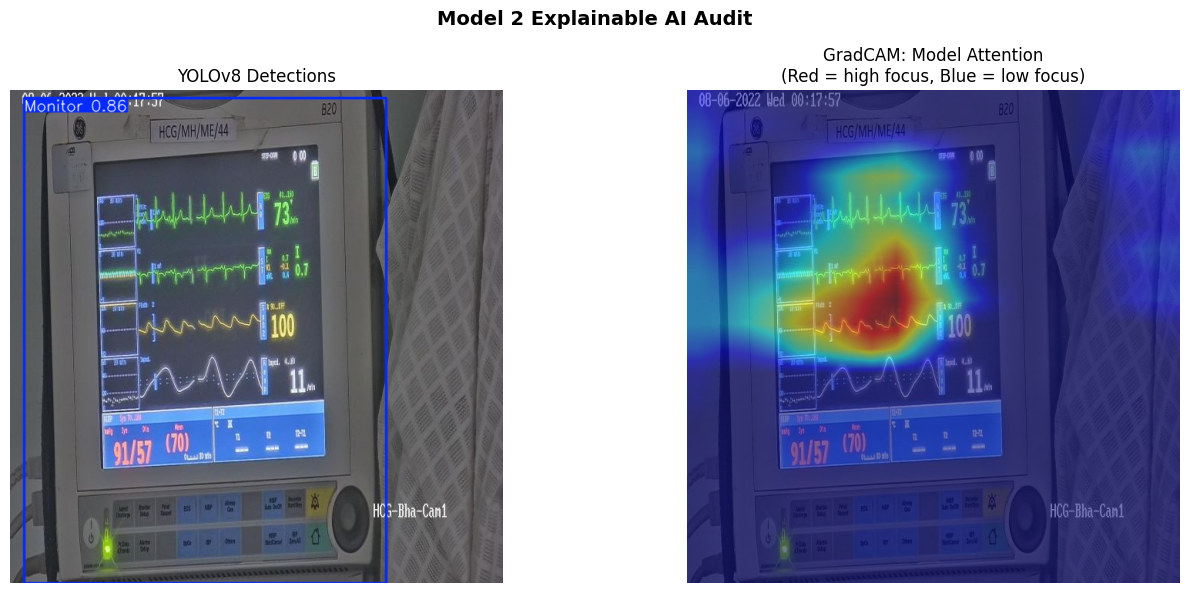


GradCAM saved to /kaggle/working/gradcam_output.png


In [25]:
# ================================
# GradCAM Visualization for YOLOv8
# Explainable AI for Model 2
# ================================

!pip install grad-cam --quiet

import os
import glob
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image


# ================================
# Load trained YOLOv8 model
# ================================

best_model = YOLO(best_model_path)


# ================================
# Wrapper so GradCAM can read YOLO output
# ================================

class YOLOv8Wrapper(nn.Module):
    
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        
        outputs = self.model(x)

        # YOLO returns tuple/list
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        return outputs


wrapped_model = YOLOv8Wrapper(best_model.model)


# ================================
# Select a test image
# ================================

test_images = glob.glob(
    "/kaggle/input/datasets/akangaandrew/hospinav/"
    "Hospital.v1-hospitaldata.yolov8/test/images/*.jpg"
)

test_image_path = test_images[0]

print("Running GradCAM on:", os.path.basename(test_image_path))


# ================================
# Run YOLO detection normally
# ================================

detection_result = best_model(test_image_path)
detection_img = detection_result[0].plot()


# ================================
# Load and preprocess image
# ================================

original = np.array(Image.open(test_image_path).convert("RGB"))

# Resize to YOLO input size
img = cv2.resize(original, (640,640))

img_float = img.astype(np.float32) / 255.0

input_tensor = torch.from_numpy(
    img_float.transpose(2,0,1)
).unsqueeze(0).float()


# ================================
# Choose YOLO backbone layer
# ================================

target_layer = wrapped_model.model.model[-2]


# ================================
# Run EigenCAM
# ================================

cam = EigenCAM(
    model=wrapped_model,
    target_layers=[target_layer]
)

grayscale_cam = cam(input_tensor=input_tensor)[0]

cam_image = show_cam_on_image(
    img_float,
    grayscale_cam,
    use_rgb=True
)


# ================================
# Plot results
# ================================

fig, axes = plt.subplots(1,2,figsize=(14,6))

axes[0].imshow(cv2.cvtColor(detection_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("YOLOv8 Detections")
axes[0].axis("off")

axes[1].imshow(cam_image)
axes[1].set_title(
    "GradCAM: Model Attention\n"
    "(Red = high focus, Blue = low focus)"
)
axes[1].axis("off")

plt.suptitle(
    "Model 2 Explainable AI Audit",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/gradcam_output.png",
    dpi=150
)

plt.show()


print("\nGradCAM saved to /kaggle/working/gradcam_output.png")

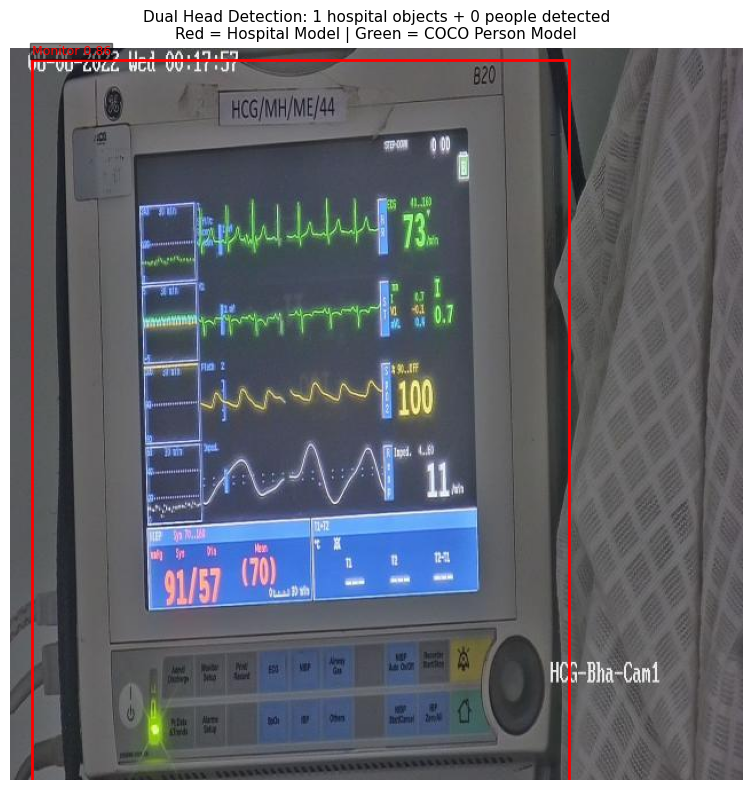


Total detections: 1
  Monitor         conf=0.86  source=hospital


In [26]:
from ultralytics import YOLO
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

# Load both models
hospital_model = YOLO(best_model_path)      # your fine-tuned model
coco_model     = YOLO("yolov8s.pt")         # pretrained COCO model

hospital_classes = ["Monitor", "bed", "sofa", "tools_table",
                    "stool", "Saline Stand", "chair", "bin"]

def dual_head_inference(image_path, conf_threshold=0.25, iou_threshold=0.5):
    """
    Run both models on the same image and merge detections.
    Hospital model detects equipment.
    COCO model detects people.
    NMS removes any overlapping duplicate boxes.
    """

    image = np.array(Image.open(image_path).convert("RGB"))

    # Run hospital model
    hospital_results = hospital_model(image_path, conf=conf_threshold, verbose=False)

    # Run COCO model but only keep person detections (class 0 in COCO)
    coco_results = coco_model(image_path, conf=conf_threshold,
                              classes=[0], verbose=False)

    # Collect all detections
    all_detections = []

    for r in hospital_results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf  = float(box.conf[0])
            cls   = int(box.cls[0])
            label = hospital_classes[cls] if cls < len(hospital_classes) else str(cls)
            all_detections.append({
                "box":    [x1, y1, x2, y2],
                "conf":   conf,
                "label":  label,
                "source": "hospital"
            })

    for r in coco_results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf  = float(box.conf[0])
            all_detections.append({
                "box":    [x1, y1, x2, y2],
                "conf":   conf,
                "label":  "person",
                "source": "coco"
            })

    # Visualise
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(image)

    colors = {"hospital": "red", "coco": "lime"}

    for det in all_detections:
        x1, y1, x2, y2 = det["box"]
        color = colors[det["source"]]

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 5,
                f"{det['label']} {det['conf']:.2f}",
                color=color, fontsize=9,
                bbox=dict(facecolor="black", alpha=0.5, pad=1))

    ax.set_title(
        f"Dual Head Detection: "
        f"{sum(1 for d in all_detections if d['source']=='hospital')} hospital objects + "
        f"{sum(1 for d in all_detections if d['source']=='coco')} people detected\n"
        f"Red = Hospital Model | Green = COCO Person Model",
        fontsize=11
    )
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("/kaggle/working/dual_head_output.png", dpi=150)
    plt.show()

    return all_detections

# Run on a test image
detections = dual_head_inference(test_images[0])
print(f"\nTotal detections: {len(detections)}")
for d in detections:
    print(f"  {d['label']:<15} conf={d['conf']:.2f}  source={d['source']}")
